In [20]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Фіксуємо seed
RANDOM_STATE = 30
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [21]:
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/nlp'):
        !git clone -b lab-06-branch --single-branch https://github.com/jaYulichka46/nlp.git
    
    %cd /content/nlp
    !pip install pandas numpy scikit-learn matplotlib seaborn -q
    sys.path.append('/content/nlp')

    FOLDER_ID = '1Xhu4xjZpRu-RP730-hyErp5F0C3l_EvO'
    
    os.makedirs('data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O data/
    
    data_dir = 'data/processed_v2'
else:
    sys.path.append(os.path.abspath('..'))
    data_dir = '../data/processed_v2'

In [22]:
print(os.listdir(data_dir))

['.gitkeep', 'processed_v_2.csv']


In [23]:
df = pd.read_csv(os.path.join(data_dir, 'processed_v_2.csv'))
print(df.shape)

(120417, 2)


In [24]:
text_column = 'lemma_text' if 'lemma_text' in df.columns else 'processed_text'
target_column = 'target'

df = df.dropna(subset=[text_column, target_column]).reset_index(drop=True)

print(f"Для тексту використовуємо колонку: '{text_column}'")
print(f"Для класів використовуємо колонку: '{target_column}'")

Для тексту використовуємо колонку: 'processed_text'
Для класів використовуємо колонку: 'target'


Розподіл категорій новин:
 - політика: 40364 текстів (33.5%)
 - спорт: 28438 текстів (23.6%)
 - новини: 25209 текстів (20.9%)
 - бізнес: 14759 текстів (12.3%)
 - технології: 11647 текстів (9.7%)


C:\Users\mfese\AppData\Local\Temp\ipykernel_13728\3282514957.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


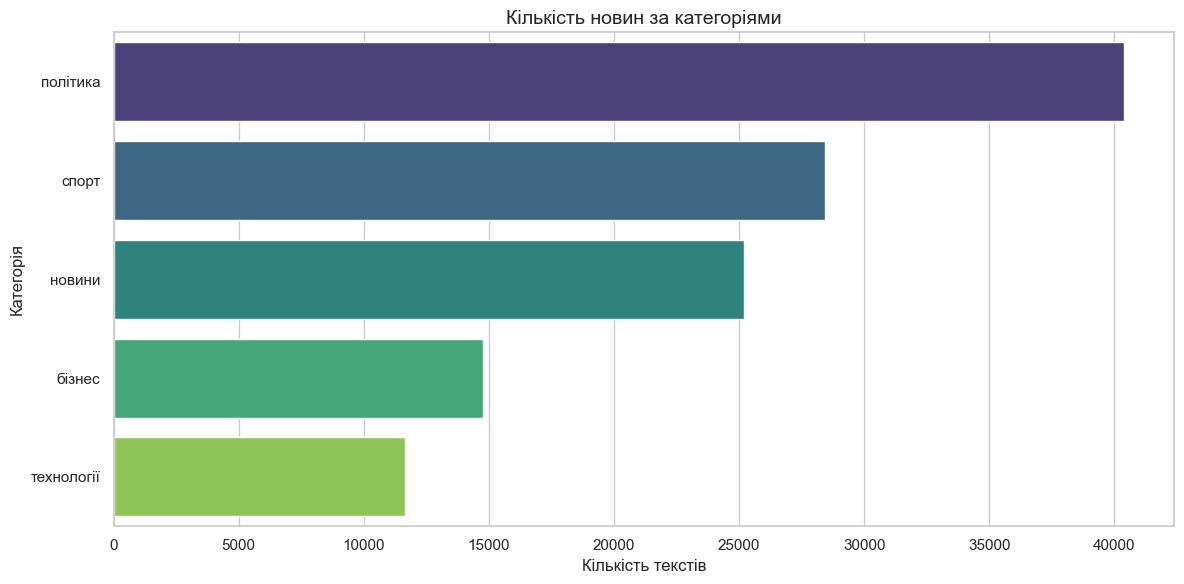

In [25]:
class_counts = df[target_column].value_counts()
class_percentages = df[target_column].value_counts(normalize=True) * 100

print("Розподіл категорій новин:")
for cat, count, perc in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f" - {cat}: {count} текстів ({perc:.1f}%)")

# Візуалізація дисбалансу
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Кількість новин за категоріями", fontsize=14)
plt.xlabel("Кількість текстів")
plt.ylabel("Категорія")
plt.tight_layout()
plt.show()

In [26]:
X = df[text_column]
y = df[target_column]

# 1. Відділяємо 20% на тестову вибірку (Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. З решти (80%) беремо 20% на валідацію (Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE, stratify=y_temp
)

print("Розміри фінальних вибірок:")
print(f"Train: {X_train.shape[0]} текстів ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} текстів ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} текстів ({len(X_test)/len(X)*100:.1f}%)")

print("\nПеревірка стратифікації (відсоток кожної категорії у Train та Test):")
train_dist = y_train.value_counts(normalize=True).round(3) * 100
test_dist = y_test.value_counts(normalize=True).round(3) * 100

dist_df = pd.DataFrame({'Train %': train_dist, 'Test %': test_dist})
display(dist_df)

Розміри фінальних вибірок:
Train: 77066 текстів (64.0%)
Val:   19267 текстів (16.0%)
Test:  24084 текстів (20.0%)

Перевірка стратифікації (відсоток кожної категорії у Train та Test):


,Train %,Test %
target,,
політика,33.5,33.5
спорт,23.6,23.6
новини,20.9,20.9
бізнес,12.3,12.3
технології,9.7,9.7


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Baseline 1: Стандартна багатокласова Логістична Регресія
pipeline_b1 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, max_features=15000)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)) # Прибрали multi_class
])

# Baseline 2: Багатокласова Логістична Регресія з балансуванням класів
pipeline_b2 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, max_features=15000)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')) # Прибрали multi_class
])

In [28]:
print("Baseline 1")
pipeline_b1.fit(X_train, y_train)

print("Baseline 2")
pipeline_b2.fit(X_train, y_train)

def evaluate_model(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average='macro')
    return acc, macro_f1

# Оцінка на Validation Set
acc_b1_val, f1_b1_val = evaluate_model(pipeline_b1, X_val, y_val, "Baseline 1")
acc_b2_val, f1_b2_val = evaluate_model(pipeline_b2, X_val, y_val, "Baseline 2")

# Оцінка на Test Set
acc_b1_test, f1_b1_test = evaluate_model(pipeline_b1, X_test, y_test, "Baseline 1")
acc_b2_test, f1_b2_test = evaluate_model(pipeline_b2, X_test, y_test, "Baseline 2")

# Виводимо результати
results_df = pd.DataFrame({
    'Model': ['Baseline 1 (Standard)', 'Baseline 2 (Balanced)'],
    'Val Accuracy': [acc_b1_val, acc_b2_val],
    'Val Macro-F1': [f1_b1_val, f1_b2_val],
    'Test Accuracy': [acc_b1_test, acc_b2_test],
    'Test Macro-F1': [f1_b1_test, f1_b2_test]
})

print("\nПорівняння моделей (Accuracy & Macro-F1):")
display(results_df.round(4))

# Визначаємо переможця по Test Macro-F1
best_model_name = "Baseline 1" if f1_b1_test > f1_b2_test else "Baseline 2"
best_pipeline = pipeline_b1 if f1_b1_test > f1_b2_test else pipeline_b2

print(f"\nНайкраща модель за Macro-F1: {best_model_name}")

Baseline 1
Baseline 2

Порівняння моделей (Accuracy & Macro-F1):


,Model,Val Accuracy,Val Macro-F1,Test Accuracy,Test Macro-F1
0,Baseline 1 (Standard),0.9157,0.9121,0.9187,0.9131
1,Baseline 2 (Balanced),0.9133,0.9100,0.9145,0.9100



Найкраща модель за Macro-F1: Baseline 1


              precision    recall  f1-score   support

      бізнес       0.89      0.88      0.88      2952
      новини       0.87      0.85      0.86      5042
    політика       0.91      0.93      0.92      8073
       спорт       0.99      0.99      0.99      5688
  технології       0.91      0.92      0.91      2329

    accuracy                           0.92     24084
   macro avg       0.91      0.91      0.91     24084
weighted avg       0.92      0.92      0.92     24084



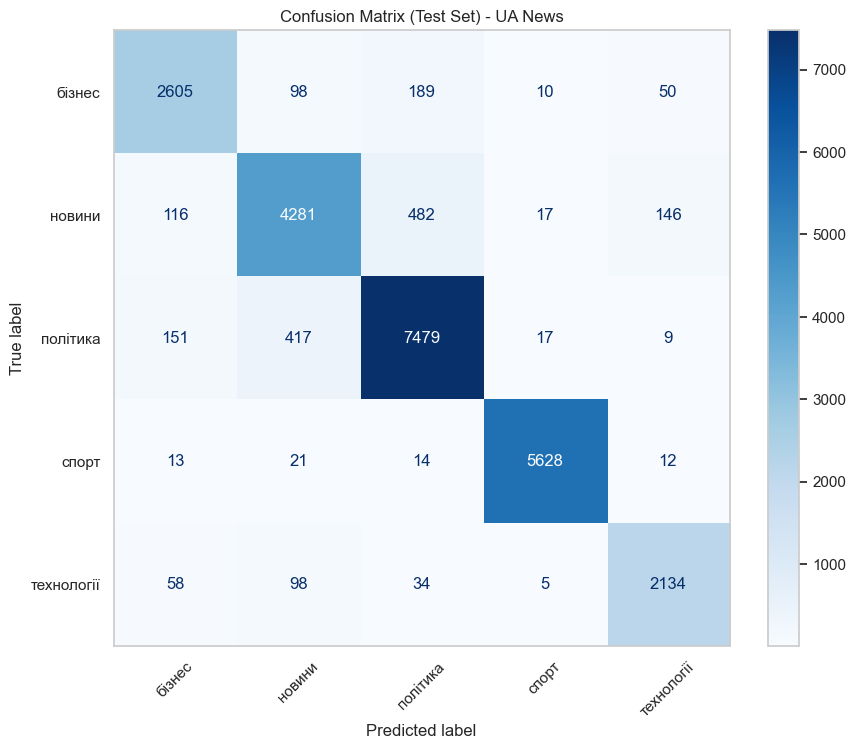

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best))

# Побудова багатокласової Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best, labels=best_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', xticks_rotation=45)
plt.title('Confusion Matrix (Test Set) - UA News')
plt.grid(False)
plt.show()

In [30]:
# Секція 8: Top Features
vectorizer = best_pipeline.named_steps['tfidf']
clf = best_pipeline.named_steps['clf']

feature_names = np.array(vectorizer.get_feature_names_out())

print("ТОП-10 ознак для кожної рубрики новин:\n")
for i, class_label in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_positive_indices = coefs.argsort()[-10:][::-1]
    top_features = feature_names[top_positive_indices]
    top_weights = coefs[top_positive_indices]
    
    print(f"Клас: {class_label}")
    for feat, weight in zip(top_features, top_weights):
        print(f"   {weight:+7.3f} * {feat}")
    print("-" * 30)

ТОП-10 ознак для кожної рубрики новин:

Клас: бізнес
    +8.423 * нагадаємо що
    +7.319 * нв
    +5.731 * бізнес
    +5.041 * компанії
    +4.803 * нв бізнес
    +4.075 * млрд
    +3.832 * повідомлялося
    +3.809 * як повідомлялося
    +3.267 * україні
    +3.204 * млн
------------------------------
Клас: новини
    +9.197 * про це
    +7.662 * це повідомляє
    +6.780 * еспресо
    +5.958 * повідомляє
    +5.325 * читайте також
    +4.781 * про
    +4.755 * передає
    +4.665 * це
    +4.112 * та
    +3.719 * tv
------------------------------
Клас: політика
    +8.762 * про це
    +5.520 * повідомляє
    +5.515 * передає
    +5.166 * еспресо tv
    +4.918 * це повідомляє
    +4.801 * tv
    +4.437 * про
    +4.255 * це
    +4.253 * еспресо
    +4.087 * росії
------------------------------
Клас: спорт
    +5.204 * динамо
    +5.181 * матчі
    +4.712 * клубу
    +4.346 * матч
    +4.282 * клуб
    +4.102 * збірної
    +3.774 * ліги
    +3.694 * матчу
    +3.665 * команди
    +3.433 

In [31]:
# Error Analysis
import json
import os

errors_mask = y_test != y_pred_best
X_errors = X_test[errors_mask]
y_errors_true = y_test[errors_mask]
y_errors_pred = y_pred_best[errors_mask]

errors_df = pd.DataFrame({
    'text': X_errors,
    'true_label': y_errors_true,
    'predicted_label': y_errors_pred
})

sampled_errors = errors_df.sample(n=15, random_state=RANDOM_STATE)

print(f"Всього помилок: {len(errors_df)} з {len(X_test)} текстів.\n")
print("Ось 15 відібраних кейсів:\n")

error_list_for_json = []

for idx, (original_index, row) in enumerate(sampled_errors.iterrows(), 1):
    print(f"Кейс #{idx} [Index: {original_index}]")
    print(f"Текст: {str(row['text'])[:300]}...") 
    print(f"Gold: {row['true_label']} | Predicted: {row['predicted_label']}")
    print("-" * 70)
    
    error_list_for_json.append({
        "text_id": int(original_index),
        "text": str(row['text']),
        "gold_label": str(row['true_label']),
        "predicted_label": str(row['predicted_label']),
        "comment": "TODO: додати коментар (напр. overlap рубрик)"
    })

os.makedirs("../tests", exist_ok=True)
error_file_path = "../tests/error_cases_lab6_ua.jsonl"

with open(error_file_path, "w", encoding="utf-8") as f:
    for item in error_list_for_json:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"\n15 помилок збережено у {error_file_path}")

Всього помилок: 1957 з 24084 текстів.

Ось 15 відібраних кейсів:

Кейс #1 [Index: 30642]
Текст: З 2020 року в календарі Формули-1 з’явиться гонка у В’єтнамі, яка пройде вулицями Ханоя. Проектувальники і архітектори траси за допомогою комп’ютерної графіки показали, як виглядатиме трек....
Gold: спорт | Predicted: технології
----------------------------------------------------------------------
Кейс #2 [Index: 39042]
Текст: Про це повідомляють у пресслужбі Нацбанку. Відомо, що компанія Коломойського надала Нацбанку нерухомість в іпотеку за кредитом рефінансування, який НБУ видав ПриватБанку. Загальна площа переданого нежитлового приміщення складає 20 тисяч квадратних метрів, а вартість перевищує 100 млн грн. “Оскільки ...
Gold: політика | Predicted: бізнес
----------------------------------------------------------------------
Кейс #3 [Index: 29130]
Текст: Поспілкуйтеся з людьми з бізнесу, які досягли успіхів, і ви переконаєтеся — в кожному з них є ця аристотелівська здатність жартувати н

In [32]:
os.makedirs("../docs", exist_ok=True)
audit_file_path = "../docs/audit_summary_lab6.md"

audit_content = f"""# Audit Summary: Lab 6 (UA News - Multiclass Classification)

## 1. Classification Subtask
**Напрям А (Text Classification).** Багатокласова класифікація текстів українських новин за 5 рубриками (політика, спорт, новини, бізнес, технології).

## 2. Dataset Split
Використано Stratified Split (64/16/20) для збереження природного дисбалансу класів (де політика займає 33.5%, а технології — 9.7%).
* **Train:** {X_train.shape[0]} текстів
* **Validation:** {X_val.shape[0]} текстів
* **Test:** {X_test.shape[0]} текстів

## 3. Оцінка Baseline-моделей
### Baseline 1 (Standard Multiclass Logistic Regression)
* **Accuracy (Test):** {acc_b1_test:.4f}
* **Macro-F1 (Test):** {f1_b1_test:.4f}

### Baseline 2 (Balanced Multiclass Logistic Regression)
* **Accuracy (Test):** {acc_b2_test:.4f}
* **Macro-F1 (Test):** {f1_b2_test:.4f}

## 4. Аналіз результатів
Baseline 1 показав себе трохи краще. Оскільки навіть найменший клас має понад 11 тисяч прикладів, штучне балансування (`class_weight='balanced'`) не дало приросту, а лише додало шуму для великих класів.

## 5. Типові помилки (Error Analysis Categories)
Під час аналізу 15 помилок та Top Features виявлено наступні проблеми:
1. **Data Leakage / Suspicious Tokens:** Найбільша проблема. Модель вивчила назви інформагентств ("еспресо", "нв", "24 канал") замість реальної семантики. Якщо "еспресо" частіше пише про політику, модель автоматично відносить туди будь-яку новину з цим словом.
2. **Overlap класів:** Сильне перетинання рубрик "Політика", "Бізнес" та "Новини" (наприклад, новини про санкції або державні бюджети).
3. **Недостатньо контексту:** Дуже короткі новини (1-2 речення), за якими важко визначити конкретну рубрику.

**Наступні кроки:** Жорстка чистка текстів від назв видань (маркерів джерел) для усунення витоку даних.
"""

with open(audit_file_path, "w", encoding="utf-8") as f:
    f.write(audit_content)

print(f"Файл успішно згенеровано: {audit_file_path}")

Файл успішно згенеровано: ../docs/audit_summary_lab6.md
